# Principal Components Analysis Nutrition Exercise
En este ejercicio no vas a montar ningún modelo de Machine Learning supervisado, sino aprenderás a trabajar con PCA: pretratar el dato antes de calcular sus PCs, interpretarlos, graficar y escoger número de componentes según varianza.

Importa las librerías necesarias

In [1]:
# Tratamiento de datos
# ==============================================================================
import numpy as np
import pandas as pd


# Gráficos
# ==============================================================================
import matplotlib.pyplot as plt
from matplotlib import style
style.use('ggplot') or plt.style.use('ggplot')

# Preprocesado y modelado
# ==============================================================================
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Configuración warnings
# ==============================================================================
import warnings
warnings.filterwarnings('ignore')

### Importa los datos
1. Importa los datos: *nndb.csv*
2. Observa las columnas que hay, así como su tipo.

In [2]:
# Dataset
nutri = pd.read_csv('data/nndb_flat.csv')
nutri.head()

,ID,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,...,Folate_USRDA,Niacin_USRDA,Riboflavin_USRDA,Thiamin_USRDA,Calcium_USRDA,Copper_USRDA,Magnesium_USRDA,Phosphorus_USRDA,Selenium_USRDA,Zinc_USRDA
0,1001,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000000,0.004762,0.034286,0.018182,0.008182
1,1002,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,...,0.0075,0.002625,0.026154,0.004167,0.020000,0.000018,0.004762,0.032857,0.018182,0.004545
2,1003,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,...,0.0000,0.000188,0.003846,0.000833,0.003333,0.000001,0.000000,0.004286,0.000000,0.000909
3,1004,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,...,0.0900,0.063500,0.293846,0.024167,0.440000,0.000044,0.054762,0.552857,0.263636,0.241818
4,1005,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,...,0.0500,0.007375,0.270000,0.011667,0.561667,0.000027,0.057143,0.644286,0.263636,0.236364


In [3]:
nutri.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8618 entries, 0 to 8617
Data columns (total 45 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ID                8618 non-null   int64  
 1   FoodGroup         8618 non-null   object 
 2   ShortDescrip      8618 non-null   object 
 3   Descrip           8618 non-null   object 
 4   CommonName        1063 non-null   object 
 5   MfgName           1560 non-null   object 
 6   ScientificName    732 non-null    object 
 7   Energy_kcal       8618 non-null   float64
 8   Protein_g         8618 non-null   float64
 9   Fat_g             8618 non-null   float64
 10  Carb_g            8618 non-null   float64
 11  Sugar_g           8618 non-null   float64
 12  Fiber_g           8618 non-null   float64
 13  VitA_mcg          8618 non-null   float64
 14  VitB6_mg          8618 non-null   float64
 15  VitB12_mcg        8618 non-null   float64
 16  VitC_mg           8618 non-null   float64


### Mira la correlación entre las variables numéricas
¿Qué pasa con las columnas USRDA? ¿Hay que tomar alguna decisión?

In [4]:
# Crear el DataFrame solo con variables numéricas
nutri_num = nutri.select_dtypes(include=np.number)

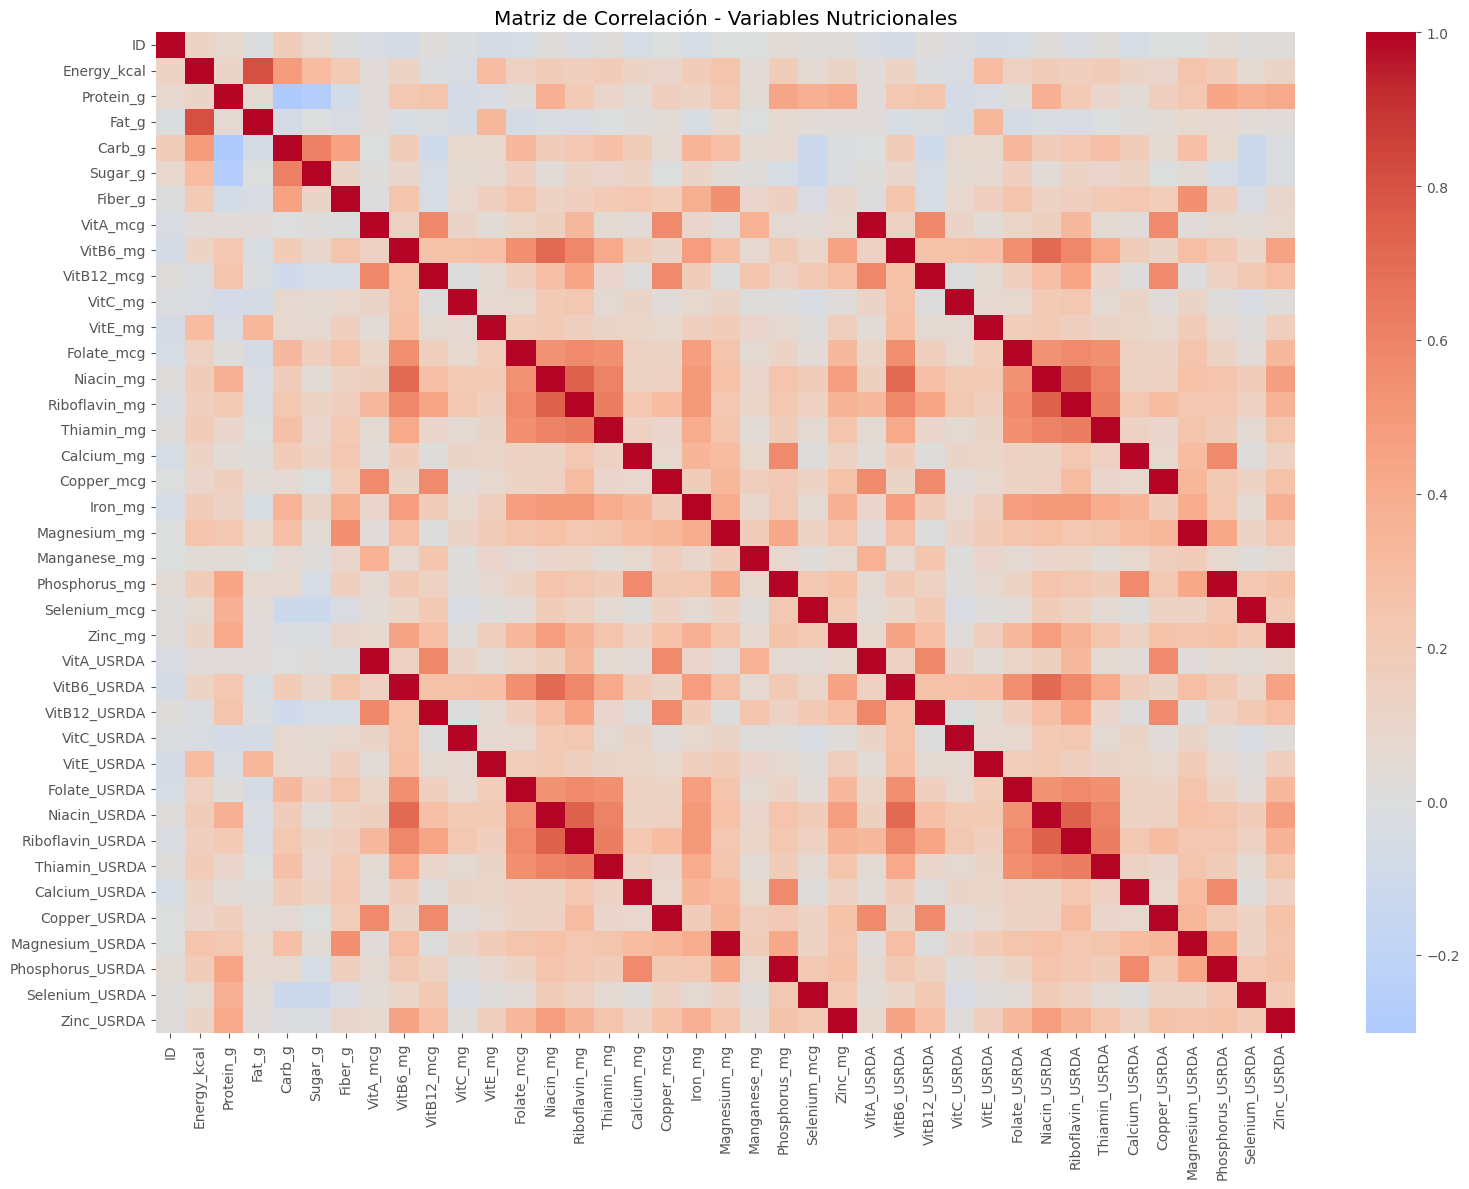

Columnas USRDA encontradas: 15
['VitA_USRDA', 'VitB6_USRDA', 'VitB12_USRDA', 'VitC_USRDA', 'VitE_USRDA', 'Folate_USRDA', 'Niacin_USRDA', 'Riboflavin_USRDA', 'Thiamin_USRDA', 'Calcium_USRDA', 'Copper_USRDA', 'Magnesium_USRDA', 'Phosphorus_USRDA', 'Selenium_USRDA', 'Zinc_USRDA']

--- ANÁLISIS DE CORRELACIÓN USRDA ---

Correlaciones de VitA_USRDA:
VitA_mcg            1.000000
VitB12_USRDA        0.581004
VitB12_mcg          0.581004
Copper_USRDA        0.569945
Copper_mcg          0.569945
Manganese_mg        0.369993
Riboflavin_mg       0.325709
Riboflavin_USRDA    0.325709
Niacin_USRDA        0.151679
Niacin_mg           0.151679
Name: VitA_USRDA, dtype: float64

Correlaciones de VitB6_USRDA:
VitB6_mg            1.000000
Niacin_USRDA        0.714143
Niacin_mg           0.714143
Riboflavin_mg       0.581678
Riboflavin_USRDA    0.581678
Folate_mcg          0.550087
Folate_USRDA        0.550087
Iron_mg             0.477905
Zinc_mg             0.447143
Zinc_USRDA          0.447143
Name: Vit

In [5]:
# Calculamos la matriz de correlación de todas las variables numéricas
correlation_matrix = nutri_num.corr()

# Visualizamos la matriz de correlación con un heatmap
import seaborn as sns
plt.figure(figsize=(16, 12))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', center=0)
plt.title('Matriz de Correlación - Variables Nutricionales')
plt.tight_layout()
plt.show()

# Identificamos las columnas USRDA (% Daily Value)
usrda_columns = [col for col in nutri_num.columns if 'USRDA' in col or '%' in col]
print(f"Columnas USRDA encontradas: {len(usrda_columns)}")
print(usrda_columns)

# Analizamos la correlación de las columnas USRDA con el resto
print("\n--- ANÁLISIS DE CORRELACIÓN USRDA ---")
for col in usrda_columns:
    correlations = correlation_matrix[col].sort_values(ascending=False)
    # Excluimos la correlación consigo misma
    correlations = correlations[correlations.index != col]
    print(f"\nCorrelaciones de {col}:")
    print(correlations.head(10))

# CONCLUSIÓN: Las columnas USRDA tienen una correlación muy alta entre ellas
# Esto significa que son redundantes - miden la misma información de formas diferentes
# DECISIÓN: Se deben eliminar todas las columnas USRDA excepto una (o eliminarlas todas)
# para evitar multicolinealidad y redundancia en el PCA

In [6]:
#Eliminamos las columnas USRDA e ID
nutri_cleaned = nutri.drop(columns=usrda_columns + ['ID'])
nutri_cleaned.head()

,FoodGroup,ShortDescrip,Descrip,CommonName,MfgName,ScientificName,Energy_kcal,Protein_g,Fat_g,Carb_g,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,Dairy and Egg Products,"BUTTER,WITH SALT","Butter, salted",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,Dairy and Egg Products,"BUTTER,WHIPPED,WITH SALT","Butter, whipped, with salt",NaN,NaN,NaN,717.0,0.85,81.11,0.06,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,Dairy and Egg Products,"BUTTER OIL,ANHYDROUS","Butter oil, anhydrous",NaN,NaN,NaN,876.0,0.28,99.48,0.00,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,Dairy and Egg Products,"CHEESE,BLUE","Cheese, blue",NaN,NaN,NaN,353.0,21.40,28.74,2.34,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,Dairy and Egg Products,"CHEESE,BRICK","Cheese, brick",NaN,NaN,NaN,371.0,23.24,29.68,2.79,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


### Variables no numéricas
Elimina las variables de texto del dataset

In [7]:
nutri_num_cleaned = nutri_cleaned.select_dtypes(include=np.number)
nutri_num_cleaned.head()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
0,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.17,0.0,...,0.034,0.005,24.0,0.000,0.02,2.0,0.000,24.0,1.0,0.09
1,717.0,0.85,81.11,0.06,0.06,0.0,684.0,0.003,0.13,0.0,...,0.034,0.005,24.0,0.016,0.16,2.0,0.004,23.0,1.0,0.05
2,876.0,0.28,99.48,0.00,0.00,0.0,840.0,0.001,0.01,0.0,...,0.005,0.001,4.0,0.001,0.00,0.0,0.000,3.0,0.0,0.01
3,353.0,21.40,28.74,2.34,0.50,0.0,198.0,0.166,1.22,0.0,...,0.382,0.029,528.0,0.040,0.31,23.0,0.009,387.0,14.5,2.66
4,371.0,23.24,29.68,2.79,0.51,0.0,292.0,0.065,1.26,0.0,...,0.351,0.014,674.0,0.024,0.43,24.0,0.012,451.0,14.5,2.60


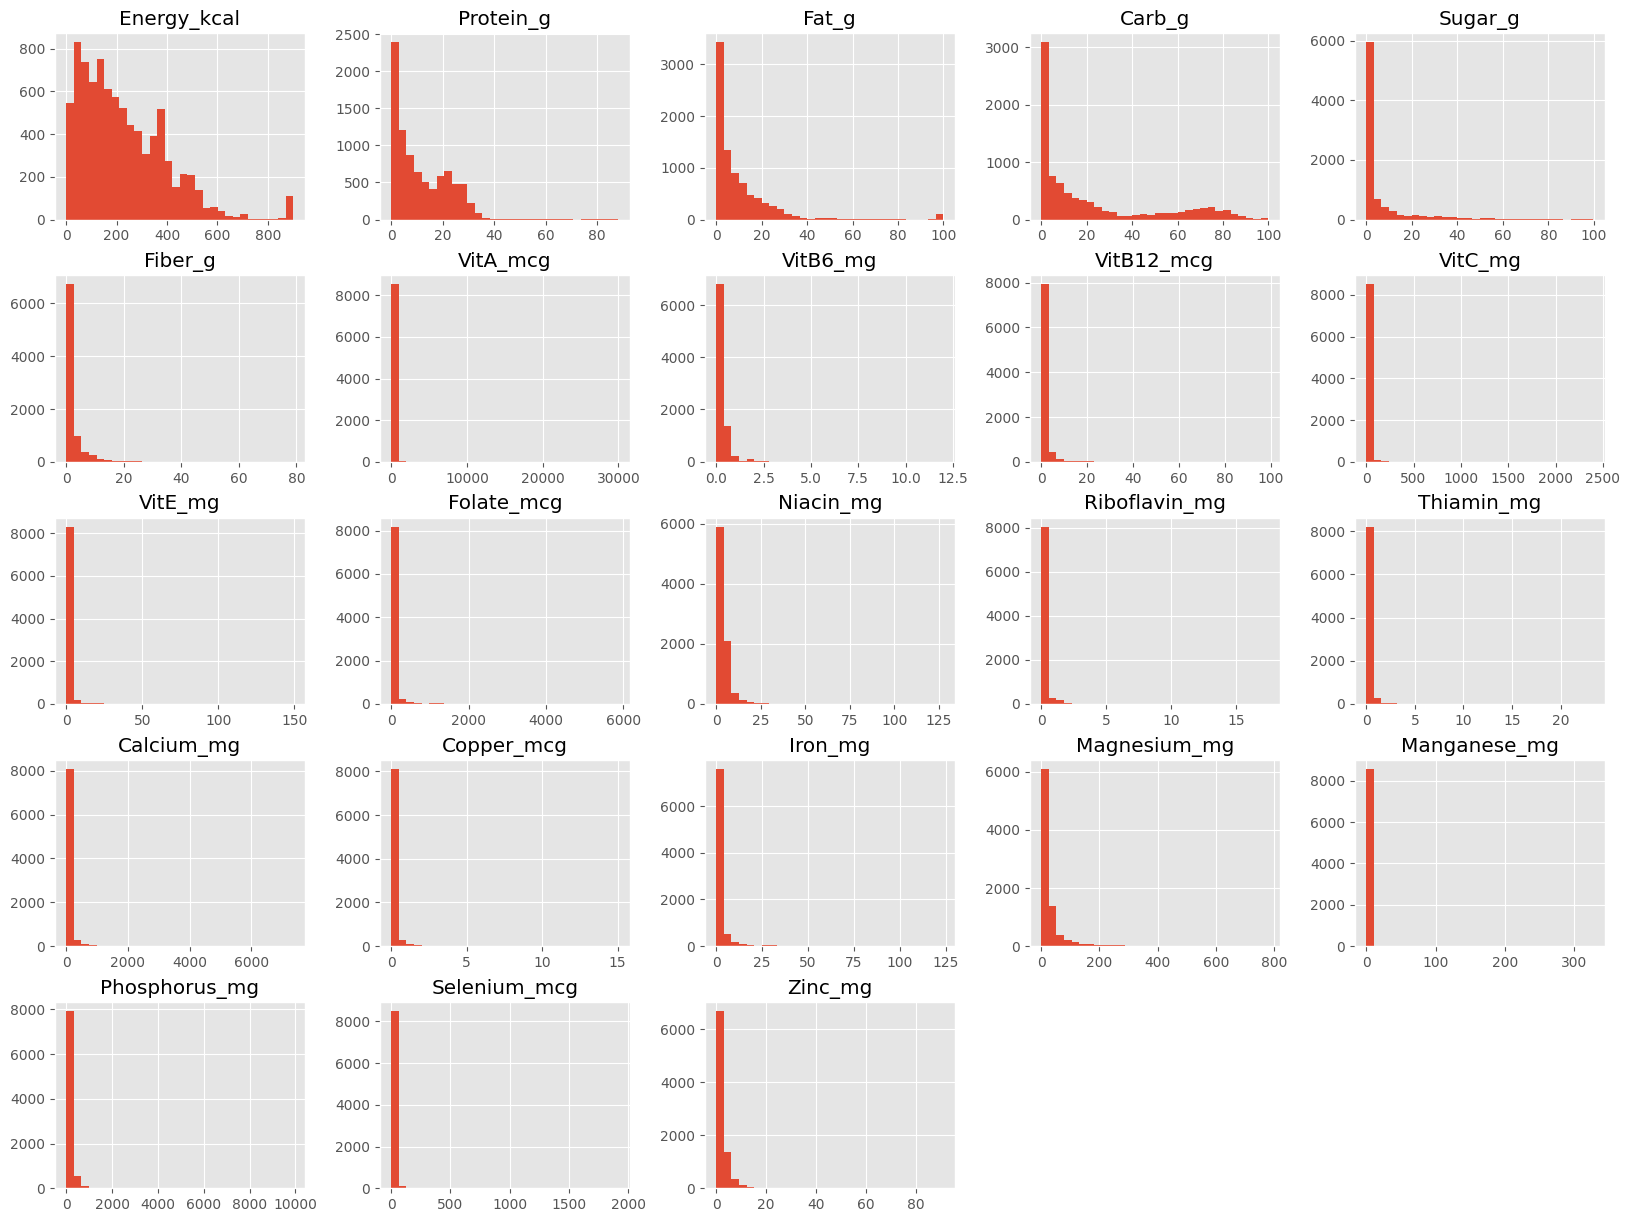

In [8]:
# Mostramos la distribución de las variables numéricas después de eliminar las columnas USRDA
nutri_num_cleaned.hist(figsize=(20, 15), bins=30);

### Distribuciones
Muchas de las variables tienen asimetría hacia la derecha. Deberíamos transformarlas para conseguir distribuciones normales y mejorar las correlaciones de cara al PCA y a futuros modelos lineales que vayamos a probar. Transforma todas las variables realizando una transformación Logarítmica.

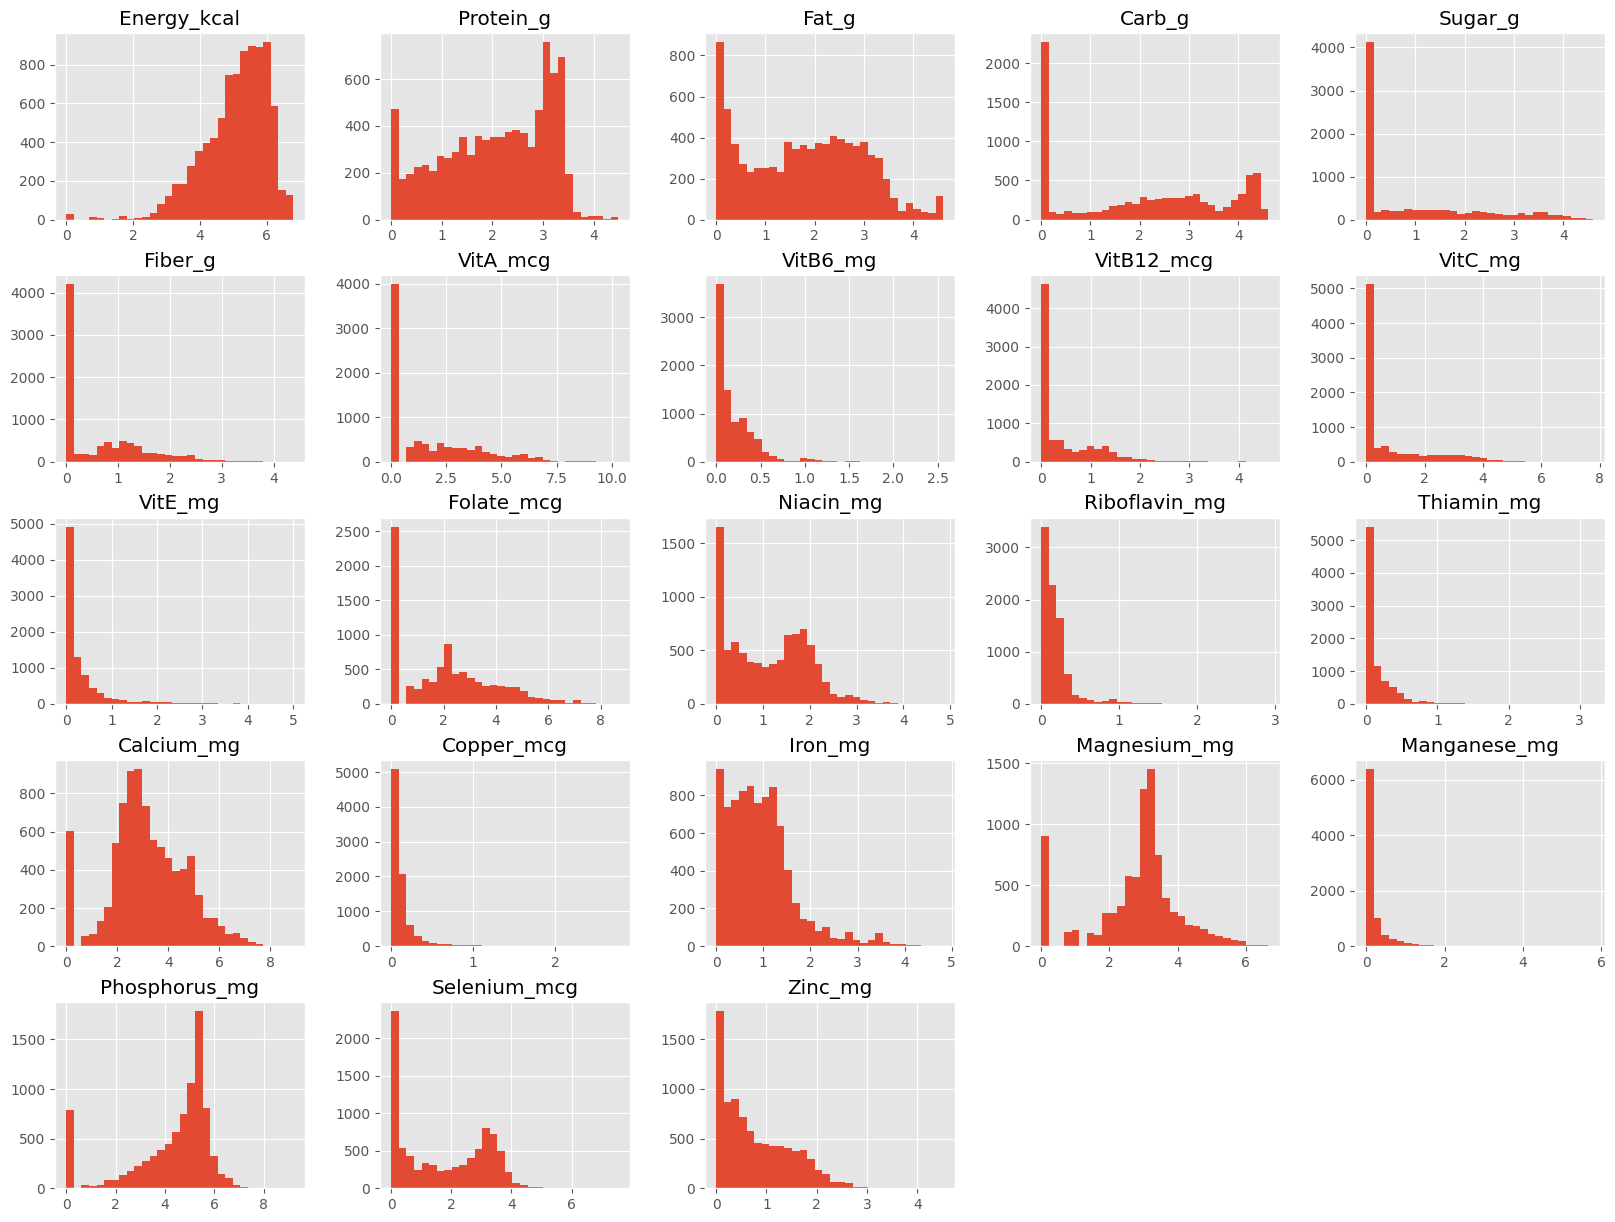

In [9]:
# Transformamos las variables numéricas con logaritmo para reducir la asimetría
nutri_num_log = np.log1p(nutri_num_cleaned)
nutri_num_log.head()
nutri_num_log.hist(figsize=(20, 15), bins=30);


In [10]:
nutri_num_log.describe()

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
count,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,...,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000,8618.000000
mean,5.075155,2.073285,1.783379,2.118534,1.018775,0.670117,1.698699,0.197749,0.454007,0.804010,...,0.181921,0.156594,3.153335,0.126583,0.939353,2.809058,0.183168,4.262292,1.698225,0.800092
std,0.974674,1.056886,1.181014,1.610507,1.278396,0.819444,2.044344,0.240045,0.654592,1.266192,...,0.216586,0.222113,1.507092,0.202792,0.712336,1.292329,0.382983,1.718525,1.434322,0.695503
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,4.543295,1.244155,0.689388,0.039221,0.000000,0.000000,0.000000,0.033676,0.000000,0.000000,...,0.044973,0.029559,2.302585,0.029559,0.425268,2.397895,0.000000,3.637586,0.095310,0.207014
50%,5.257495,2.228400,1.830178,2.297070,0.314811,0.262364,0.895880,0.113329,0.076961,0.000000,...,0.139762,0.074643,2.995732,0.076035,0.845868,3.044522,0.021761,4.897840,1.589235,0.612476
75%,5.820083,3.043450,2.701361,3.523415,1.840550,1.223775,3.091042,0.303801,0.831820,1.252763,...,0.231112,0.201307,4.143135,0.135186,1.275363,3.401197,0.200489,5.379897,3.104587,1.308333
max,6.805723,4.492225,4.615121,4.615121,4.613138,4.382027,10.308986,2.564949,4.604070,7.783641,...,2.917771,3.193558,8.904494,2.775709,4.825109,6.661855,5.796058,9.202207,7.559038,4.521245


### Estandarizado
Estandariza cada variable.

No es necesario que dividas en train y test.

In [11]:
pca_pipe = make_pipeline(StandardScaler(), PCA())
pca_pipe.fit(nutri_num_log)

modelo_pca = pca_pipe['pca']

### Implementación del PCA
Prueba a montar un PCA con todos los componentes. Para ello utiliza los datos previamente transformados y escalados.

In [12]:
# Se convierte el array a dataframe para añadir nombres a los ejes.
pd.DataFrame(
    data = modelo_pca.components_,
    columns = nutri_num_log.columns,
    index = [f'PC{i+1}' for i in range(len(modelo_pca.components_))])

,Energy_kcal,Protein_g,Fat_g,Carb_g,Sugar_g,Fiber_g,VitA_mcg,VitB6_mg,VitB12_mcg,VitC_mg,...,Riboflavin_mg,Thiamin_mg,Calcium_mg,Copper_mcg,Iron_mg,Magnesium_mg,Manganese_mg,Phosphorus_mg,Selenium_mcg,Zinc_mg
PC1,0.198045,0.277927,0.148024,0.002898,-0.026550,0.074429,0.079993,0.263414,0.215148,-0.024158,...,0.266736,0.229400,0.154403,0.188309,0.281809,0.275671,0.139021,0.295597,0.247376,0.298978
PC2,0.005434,-0.242246,-0.150170,0.439120,0.320255,0.388059,0.109656,0.007442,-0.236848,0.256138,...,0.072566,0.160926,0.204121,0.136707,0.124534,0.112675,0.259182,-0.061638,-0.225185,-0.159530
PC3,0.522265,0.079023,0.473911,0.210881,0.184202,0.136179,-0.292311,-0.159116,-0.185990,-0.394600,...,-0.096958,0.057955,-0.093723,-0.040051,0.039002,-0.073287,0.029160,-0.016400,-0.062524,-0.039190
PC4,0.064251,-0.132056,0.032874,0.038051,0.281229,-0.081251,0.086504,0.312399,0.232704,0.153351,...,0.352801,0.307120,-0.208702,-0.270591,0.124226,-0.319855,-0.327222,-0.230474,-0.164419,-0.026426
PC5,0.148431,-0.074988,0.335097,-0.094996,0.089666,-0.196324,0.544616,-0.071754,0.078367,0.127914,...,-0.046883,-0.220295,0.212893,0.008586,-0.181673,-0.044502,-0.074241,0.010867,0.095435,-0.052027
PC6,-0.056377,-0.130078,0.031900,-0.195738,-0.232627,0.056819,-0.220996,0.151959,0.055321,0.104925,...,-0.032598,-0.001320,-0.440449,0.404956,0.041904,-0.096259,0.353709,-0.273709,-0.079276,0.095311
PC7,0.056439,0.006583,0.061057,0.057248,0.124189,-0.158187,0.188459,-0.218884,0.294178,-0.082043,...,0.225303,-0.113935,0.111275,0.569171,0.176256,-0.217741,0.099441,-0.148707,-0.125677,0.076144
PC8,-0.006633,0.043613,-0.090748,-0.000223,0.484500,0.066867,-0.381964,0.084649,0.247129,0.302244,...,-0.196122,-0.395320,0.056744,0.055444,-0.003136,0.191494,-0.196760,0.103840,-0.009711,0.317642
PC9,-0.056684,0.127038,0.172536,-0.178933,-0.382132,0.168389,-0.041751,0.105078,-0.071421,0.227712,...,-0.029489,0.049271,0.489771,-0.135641,0.204857,-0.019208,0.041856,-0.019741,-0.397578,0.045342
PC10,0.295080,0.017928,0.318727,0.035122,-0.210174,-0.101103,-0.080107,-0.183531,-0.065568,0.639078,...,-0.088774,-0.001610,-0.233598,0.020123,0.103469,0.016090,-0.165279,0.021910,-0.085098,-0.002007


### Aportación de cada PCA
Visualiza en un diagrama de líneas la suma acumulada de la varianza explicativa del PCA.

Si tuviéses que quedarte con 70-75 % de la varianza original, ¿con cuántos Principal Components te quedarías?

----------------------------------------------------
Porcentaje de varianza explicada por cada componente
----------------------------------------------------


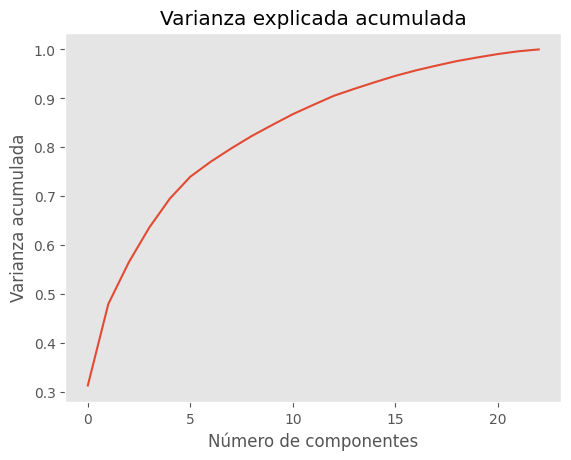

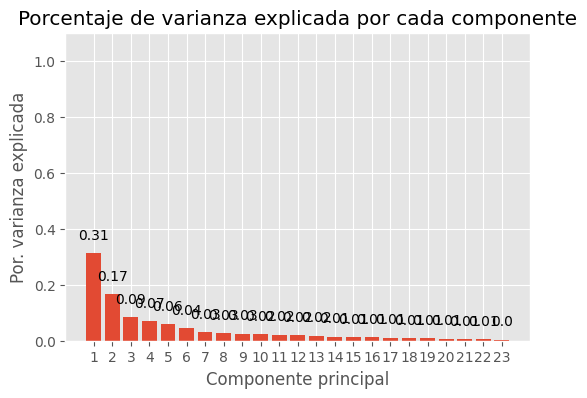

In [13]:
# Porcentaje de varianza explicada por cada componente
# ==============================================================================
print('----------------------------------------------------')
print('Porcentaje de varianza explicada por cada componente')
print('----------------------------------------------------')
varianza = modelo_pca.explained_variance_ratio_
varianza_acumulada = np.cumsum(varianza)

plt.plot(varianza_acumulada)
plt.xlabel('Número de componentes')
plt.ylabel('Varianza acumulada')
plt.title('Varianza explicada acumulada')
plt.grid()
#### CODE ####

fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(6, 4))
ax.bar(
    x      = np.arange(modelo_pca.n_components_) + 1,
    height = modelo_pca.explained_variance_ratio_
)

for x, y in zip(np.arange(len(nutri_num_log.columns)) + 1, modelo_pca.explained_variance_ratio_):
    label = round(y, 2)
    ax.annotate(
        label,
        (x,y),
        textcoords="offset points",
        xytext=(0,10),
        ha='center'
    )

ax.set_xticks(np.arange(modelo_pca.n_components_) + 1)
ax.set_ylim(0, 1.1)
ax.set_title('Porcentaje de varianza explicada por cada componente')
ax.set_xlabel('Componente principal')
ax.set_ylabel('Por. varianza explicada');

In [14]:
#Con 5 componentes ya se explica el 70-75 de la varianza, por lo que se puede reducir la dimensionalidad a 5 componentes sin perder mucha información.

## Feat. Red
Crea un nuevo PCA con X Principal Components, siendo X la cantidad de PC escogidos en el apartado anterior.

Obtén el nuevo dataset con el mismo número de registros que el original, pero en este caso con X features, que representan los PC elegidos.

In [15]:
# Proyección de las observaciones de entrenamiento
# ==============================================================================
pca_pipe = make_pipeline(StandardScaler(), PCA(n_components=6))
modelo_pca = pca_pipe['pca']
proyecciones = pca_pipe.fit_transform(X=nutri_num_log)
proyecciones = pd.DataFrame(
    proyecciones,
    columns = ['PC1', 'PC2', 'PC3', 'PC4', 'PC5','PC6'],
    index   = nutri_num_log.index
)
proyecciones.head(50)

,PC1,PC2,PC3,PC4,PC5,PC6
0,-2.139032,-0.968019,1.463988,0.270872,4.066991,0.307222
1,-2.106485,-0.909501,1.480580,0.263240,4.032459,0.348613
2,-3.267830,-1.138430,2.042335,1.175421,4.071722,1.326607
3,1.525964,-1.264102,-0.136013,-0.929808,2.430444,-2.095054
4,1.240712,-1.204120,-0.004729,-1.192002,2.691725,-2.341876
5,1.449416,-1.467204,-0.369579,-0.444270,2.277387,-1.538166
6,1.479597,-1.376023,-0.541758,-0.757242,2.425145,-1.910690
7,1.259000,-1.135450,0.060005,-1.338833,2.243765,-2.500529
8,1.527192,-1.335996,0.048471,-1.408800,3.126894,-1.952114
9,1.060788,-1.231813,0.095134,-1.423677,2.353728,-2.443726


### ¿Qué grupo de comida tiene los valores más altos en cada categoría?
Determina para cada Principal Component, los 3 grupos de comida (*FoodGroup*) con los valores del PC más altos.

In [16]:
# Añadir la columna FoodGroup a las proyecciones
proyecciones['FoodGroup'] = nutri['FoodGroup'].values

# Para cada PC, encontrar los 3 grupos de comida con valores más altos
for pc in ['PC1', 'PC2', 'PC3', 'PC4', 'PC5']:
    print(f"\n{'='*50}")
    print(f"Top 3 FoodGroups para {pc}:")
    print('='*50)
    
    # Calcular el valor medio de cada PC por grupo de comida
    pc_by_group = proyecciones.groupby('FoodGroup')[pc].mean().sort_values(ascending=False)
    
    # Mostrar los 3 grupos con valores más altos
    for i, (group, value) in enumerate(pc_by_group.head(3).items(), 1):
        print(f"{i}. {group}: {value:.3f}")
    
    # También podemos mostrar los 3 más bajos para contexto
    print(f"\nBottom 3 FoodGroups para {pc}:")
    for i, (group, value) in enumerate(pc_by_group.tail(3).items(), 1):
        print(f"{i}. {group}: {value:.3f}")



Top 3 FoodGroups para PC1:
1. Breakfast Cereals: 4.020
2. Nut and Seed Products: 3.121
3. Spices and Herbs: 2.562

Bottom 3 FoodGroups para PC1:
1. Soups, Sauces, and Gravies: -3.174
2. Beverages: -3.259
3. Fats and Oils: -3.269

Top 3 FoodGroups para PC2:
1. Spices and Herbs: 3.648
2. Breakfast Cereals: 2.748
3. Nut and Seed Products: 2.268

Bottom 3 FoodGroups para PC2:
1. Pork Products: -2.216
2. Lamb, Veal, and Game Products: -2.532
3. Beef Products: -2.754

Top 3 FoodGroups para PC3:
1. Fats and Oils: 2.334
2. Baked Products: 1.728
3. Nut and Seed Products: 1.241

Bottom 3 FoodGroups para PC3:
1. Beverages: -0.958
2. Finfish and Shellfish Products: -1.248
3. Vegetables and Vegetable Products: -1.801

Top 3 FoodGroups para PC4:
1. Breakfast Cereals: 2.265
2. Fats and Oils: 1.045
3. Beverages: 0.545

Bottom 3 FoodGroups para PC4:
1. Cereal Grains and Pasta: -1.323
2. Spices and Herbs: -1.603
3. Nut and Seed Products: -2.093

Top 3 FoodGroups para PC5:
1. Fats and Oils: 2.634
2. Dai